# Task: Sampling Theorem

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 1 - Data and Domain

### Use Case

In the context of Swiss railway infrastructure monitoring, continuous-time vertical bogie vibration signals are generated by wheel-rail interaction and acquired by onboard accelerometers to detect early defect signatures before safety-critical failures occur. These digital vibration signals are used by SBB maintenance and safety teams to support predictive maintenance decisions, including whether a wheelset requires immediate inspection or can remain in service. This use case is particularly relevant for Switzerland because high tunnel density, alpine routes, and strict safety expectations require reliable early-warning diagnostics under regular passenger operation.

### Problem Statement

This project addresses the problem of selecting an appropriate sampling rate for accelerometer-based bogie vibration monitoring in the Swiss rail context. If the sampling rate is too low, aliasing can mask or shift defect-related frequency content and cause missed early-warning signals; if the sampling rate is unnecessarily high, storage and transmission overhead increase without proportional diagnostic benefit. Preserving diagnostically relevant frequency components is essential for reliable wheel-defect detection and risk reduction in tunnel operations.

### Experimental Objective

The objective of this project is to investigate how sampling-rate choices influence the preservation of informative vibration features within a fixed 1.0 s analysis window. The goal is to determine which reduced sampling conditions still retain sufficient short-time information for practical predictive maintenance decisions in the Swiss SBB use case.

### Data Definition, Source, and Visualization

The selected signal is a one-dimensional synthetic vertical bogie vibration measurement representing train operation at 80 km/h, expressed in normalised acceleration units [a.u.]. The generated signal has duration 60 seconds at 575 Hz, so it contains 34,500 samples. It includes baseline vibration dynamics, periodic defect-like impulses, and light additive noise to emulate a realistic monitoring scenario with controlled degradation signatures. The data are generated with `generate_synthetic_signal.py` and loaded from `data/synthetic_defect_signal.npy`. This controlled synthetic source is appropriate for sampling-theorem experiments because it enables reproducible comparison of downsampling effects while preserving known defect-related structure.

Signal path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/synthetic_defect_signal.npy
Signal shape: (34500,), dtype: float64
Loaded event timestamps: 461
Events in first 1.0 s: 7
Signal mean=0.018972, std=0.126133, min=-0.279342, max=0.626337


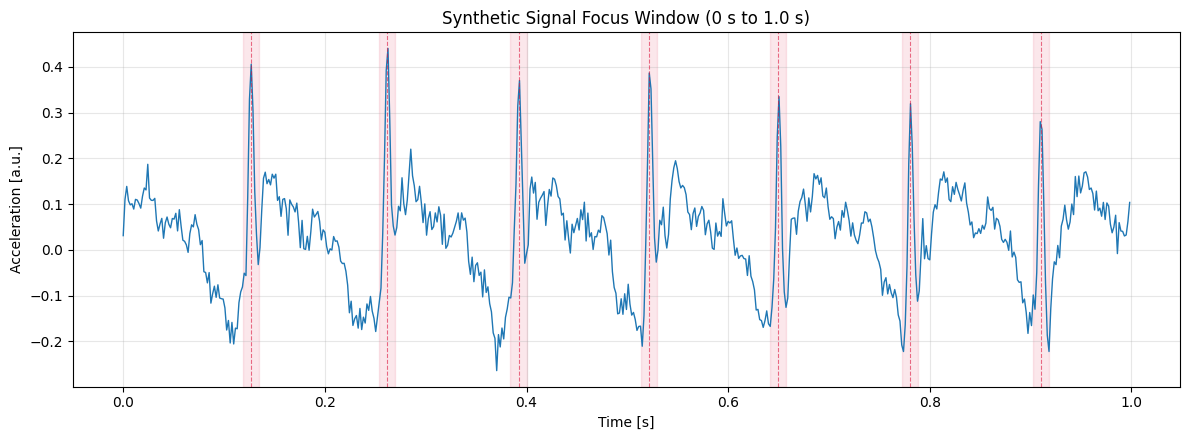

In [5]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FS_HZ = 575
DURATION_SECONDS = 60
FOCUS_WINDOW_SECONDS = 1
EVENT_MARKER_HALF_WIDTH_S = 0.008
DEFECT_CUTOUT_PRE_S = 0.03
DEFECT_CUTOUT_POST_S = 0.05

project_root = Path.cwd().resolve().parent
x_path = project_root / "data" / "synthetic_defect_signal.npy"
event_path = project_root / "data" / "synthetic_defect_signal_event_times.npy"

x_full = np.load(x_path).astype(np.float64)
event_times = np.load(event_path).astype(np.float64) if event_path.exists() else np.array([], dtype=np.float64)

assert x_full.ndim == 1, "Expected a 1D synthetic signal."
assert x_full.size == FS_HZ * DURATION_SECONDS, "Unexpected signal length for 60 s at 575 Hz."

x_ref = x_full
time_s = np.arange(x_ref.size) / FS_HZ
event_times_focus = event_times[(event_times >= 0.0) & (event_times < FOCUS_WINDOW_SECONDS)]

print(f"Signal path: {x_path}")
print(f"Signal shape: {x_ref.shape}, dtype: {x_ref.dtype}")
print(f"Loaded event timestamps: {event_times.size}")
print(f"Events in first {FOCUS_WINDOW_SECONDS:.1f} s: {event_times_focus.size}")
print(
    f"Signal mean={x_ref.mean():.6f}, std={x_ref.std():.6f}, "
    f"min={x_ref.min():.6f}, max={x_ref.max():.6f}"
)

zoom_mask = (time_s >= 0) & (time_s < FOCUS_WINDOW_SECONDS)

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.plot(time_s[zoom_mask], x_ref[zoom_mask], linewidth=1.0, label="signal")

for t_evt in event_times_focus:
    ax.axvspan(
        max(0.0, t_evt - EVENT_MARKER_HALF_WIDTH_S),
        min(FOCUS_WINDOW_SECONDS, t_evt + EVENT_MARKER_HALF_WIDTH_S),
        color="crimson",
        alpha=0.10,
    )
    ax.axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title(f"Synthetic Signal Focus Window (0 s to {FOCUS_WINDOW_SECONDS:.1f} s)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [a.u.]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations**:
The visualization focuses on the first 1.0 seconds and reveals repeated defect-related impulses, local oscillatory structure, and rapid amplitude changes that are harder to compare on long windows. This 1.0 s segment is used as the primary analysis window because it contains multiple recurring defect events and makes reconstruction differences directly interpretable for the sampling-rate experiment in the SBB predictive maintenance use case.

### Transition to Method Design
The domain context, signal source, and baseline visualization are now established. The next sections formalize the sampling-theorem assumptions and define the exact parameter sweep used for reproducible implementation and evaluation.

## Day 2 - Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the Nyquist-Shannon sampling principle to railway bogie vibration monitoring for Swiss predictive maintenance. The principle assumes that the relevant signal content is sufficiently band-limited and that anti-alias filtering is applied before decimation; under these conditions, sampling at or above twice the highest relevant frequency preserves information for analysis. A controlled downsampling-and-reconstruction workflow is selected because it operationalizes this principle and allows direct measurement of information loss in a use-case-relevant way. If assumptions are violated, aliasing and distortion can mislead defect-related interpretation.

### Parameter Definition and Mathematical Specification

For this synthetic signal, the highest defect-relevant oscillatory component is the injected ring at approximately $95\,\mathrm{Hz}$ (see generator definition in `generate_synthetic_signal.py`). We therefore use a justified practical bandwidth approximation $B\approx95\,\mathrm{Hz}$ for anti-alias-safe monitoring of the diagnostic content. From this bandwidth:

$$f_{\mathrm{Nyquist\;frequency}} = B \approx 95\,\mathrm{Hz}, \qquad f_{s,\min} = 2B \approx 190\,\mathrm{Hz}.$$

Thus the minimum Nyquist-compliant sampling rate is about $190\,\mathrm{Hz}$. The reference signal is sampled at $f_s=575\,\mathrm{Hz}$ and evaluated on a fixed window $T_w=1.0\,\mathrm{s}$, giving $N_w=f_s\cdot T_w=575$ samples with $\Delta t=1/f_s\approx1.739\,\mathrm{ms}$.

The reduced experiment set is mapped explicitly to Nyquist regimes: $384\,\mathrm{Hz}$ (above Nyquist), $192\,\mathrm{Hz}$ (approximately at Nyquist), and $48\,\mathrm{Hz}$ (well below Nyquist). In this domain, lowering $f_s'$ reduces telemetry load, while increasing reconstruction distortion indicates loss of defect-relevant short-time detail due to sampling limitations.

### Experimental Design for Next Days

The baseline configuration is the original sampled signal at $575\,\mathrm{Hz}$, evaluated on a fixed 1.0 s reference window. The reduced comparison set varies only target sampling rate with linear reconstruction, using $f_s'\in\{575,384,192,48\}\,\mathrm{Hz}$.

Relative to the derived Nyquist minimum $f_{s,\min}\approx190\,\mathrm{Hz}$:
- $384\,\mathrm{Hz}$ tests an above-Nyquist regime (high safety margin).
- $192\,\mathrm{Hz}$ tests an approximately at-Nyquist regime.
- $48\,\mathrm{Hz}$ tests a below-Nyquist regime (expected aliasing/distortion).

All metrics and visual comparisons are computed on the same first 1.0 s segment to keep the experiment internally consistent and directly comparable. It is theoretically expected that decreasing $f_s'$ increases window-level reconstruction error, with strongest degradation in the below-Nyquist regime.

### Methodological Limitations and Risk Factors

This approach assumes that the selected signal segment is representative and that relevant vibration features are sufficiently band-limited, which may be violated under transient events, non-stationarity, or changing track conditions. The method is most reliable when noise and operational variability are moderate, but can become misleading when low-frequency drift or high-frequency impulsive components dominate. In this railway use case, primary risks are segment-selection bias and aliasing-induced feature loss, potentially leading to underestimation of maintenance urgency.

## Day 3 - Implementation

In [6]:
import numpy as np
import pandas as pd


BANDWIDTH_EST_HZ = 95.0
NYQUIST_MIN_FS_HZ = 2.0 * BANDWIDTH_EST_HZ


def load_focus_window() -> np.ndarray:
    assert x_full.size == FS_HZ * DURATION_SECONDS

    focus_samples = max(1, int(FS_HZ * FOCUS_WINDOW_SECONDS))
    return x_full[:focus_samples]


def classify_sampling_regime(fs_target: int, fs_min: float, rel_tol: float = 0.05) -> str:
    if abs(fs_target - fs_min) <= rel_tol * fs_min:
        return "at_nyquist"
    if fs_target > fs_min:
        return "above_nyquist"
    return "below_nyquist"


def reconstruct_with_linear_interp(signal: np.ndarray, fs_in: int, fs_target: int) -> np.ndarray:
    target_count = int(round(signal.size * fs_target / fs_in))
    t_ref = np.arange(signal.size) / fs_in
    t_down = np.linspace(0.0, t_ref[-1], target_count)
    downsampled = np.interp(t_down, t_ref, signal)
    return np.interp(t_ref, t_down, downsampled)


def reconstruct_signal(signal: np.ndarray, fs_target: int, method: str) -> np.ndarray:
    if method == "identity":
        return signal.copy()
    if method == "linear":
        return reconstruct_with_linear_interp(signal, FS_HZ, fs_target)
    raise ValueError(f"Unsupported method: {method}")


def compute_metrics(reference: np.ndarray, candidate: np.ndarray, fs_hz: int) -> dict:
    rmse = float(np.sqrt(np.mean((reference - candidate) ** 2)))
    corr = float(np.corrcoef(reference, candidate)[0, 1])

    ref_mag = np.abs(np.fft.rfft(reference))
    cand_mag = np.abs(np.fft.rfft(candidate))
    spectral_distortion_pct = float(
        np.linalg.norm(ref_mag - cand_mag) / (np.linalg.norm(ref_mag) + 1e-12) * 100.0
    )

    return {
        "rmse": rmse,
        "corr": corr,
        "spectral_distortion_pct": spectral_distortion_pct,
    }


x_ref = load_focus_window()
experiment_configs = [
    {"config": "baseline_fs575_identity", "fs_target": 575, "method": "identity"},
    {"config": "fs384_linear", "fs_target": 384, "method": "linear"},
    {"config": "fs192_linear", "fs_target": 192, "method": "linear"},
    {"config": "fs48_linear", "fs_target": 48, "method": "linear"},
]

records = []
reconstructions = {}

print(f"Bandwidth estimate B = {BANDWIDTH_EST_HZ:.1f} Hz")
print(f"Nyquist minimum sampling rate f_s,min = 2B = {NYQUIST_MIN_FS_HZ:.1f} Hz")

for cfg in experiment_configs:
    x_rec = reconstruct_signal(x_ref, cfg["fs_target"], cfg["method"])
    reconstructions[cfg["config"]] = x_rec

    records.append(
        {
            "config": cfg["config"],
            "fs_target_hz": cfg["fs_target"],
            "sampling_regime": classify_sampling_regime(cfg["fs_target"], NYQUIST_MIN_FS_HZ),
            "method": cfg["method"],
            **compute_metrics(x_ref, x_rec, FS_HZ),
        }
    )

results_df = pd.DataFrame.from_records(records).sort_values(
    ["fs_target_hz", "method"], ascending=[False, True]
)
results_df


Bandwidth estimate B = 95.0 Hz
Nyquist minimum sampling rate f_s,min = 2B = 190.0 Hz


,config,fs_target_hz,sampling_regime,method,rmse,corr,spectral_distortion_pct
0,baseline_fs575_identity,575,above_nyquist,identity,0.000000,1.000000,0.000000
1,fs384_linear,384,above_nyquist,linear,0.016308,0.989573,11.934669
2,fs192_linear,192,at_nyquist,linear,0.031352,0.960029,21.963085
3,fs48_linear,48,below_nyquist,linear,0.085970,0.651967,62.739712


## Day 4 - Evaluation

### Evaluation Approach Definition

The primary quantitative metric is RMSE between each reconstructed signal and the 575 Hz baseline on the fixed 1.0 s analysis window. Complementary metrics are correlation and spectral distortion percentage, both computed on the same 1.0 s window to quantify waveform and spectrum preservation under reduced sampling. This approach is appropriate because all reported quantities are derived from a single consistent short-time segment that is directly used in the visual comparison.

### Evaluation Comparison Execution

The influence of sampling rate is evaluated on the same first 1.0 s segment using RMSE, correlation, and spectral distortion. The comparison set includes four predefined configurations: `575 Hz + identity` (baseline), `384 Hz + linear`, `192 Hz + linear`, and `48 Hz + linear`. Relative performance is reported against the baseline using window-consistent metrics only.

In addition to time-domain overlays, a frequency-domain comparison of reconstructed spectra is included to make aliasing-related distortion visually traceable for the near-Nyquist and below-Nyquist regimes. This keeps the evaluation aligned with the Nyquist framing and supports quantitative interpretation with direct spectral evidence.

Evaluation table (1.0 s window):
                 config  fs_target_hz sampling_regime   method     rmse     corr  spectral_distortion_pct  rmse_abs_increase_vs_baseline
baseline_fs575_identity           575   above_nyquist identity 0.000000 1.000000                 0.000000                       0.000000
           fs384_linear           384   above_nyquist   linear 0.016308 0.989573                11.934669                       0.016308
           fs192_linear           192      at_nyquist   linear 0.031352 0.960029                21.963085                       0.031352
            fs48_linear            48   below_nyquist   linear 0.085970 0.651967                62.739712                       0.085970


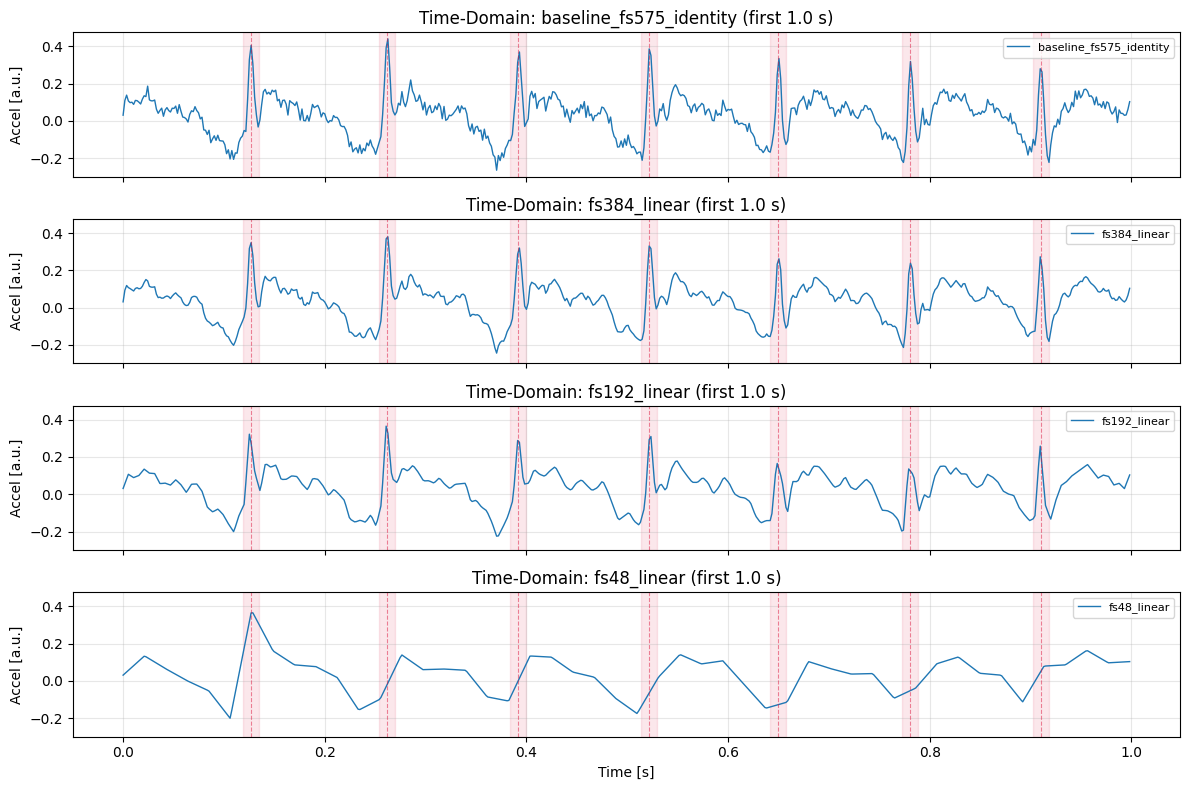

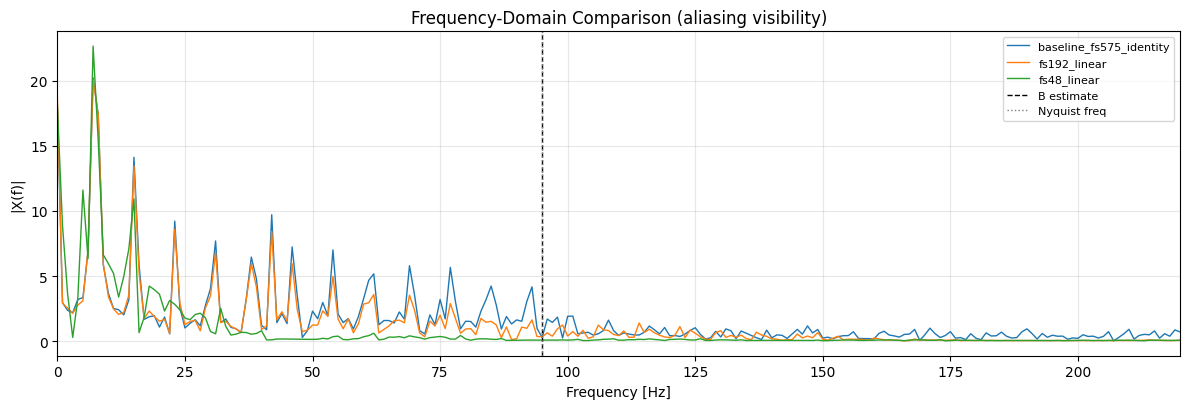

,config,fs_target_hz,sampling_regime,method,rmse,corr,spectral_distortion_pct,rmse_abs_increase_vs_baseline
0,baseline_fs575_identity,575,above_nyquist,identity,0.000000,1.000000,0.000000,0.000000
1,fs384_linear,384,above_nyquist,linear,0.016308,0.989573,11.934669,0.016308
2,fs192_linear,192,at_nyquist,linear,0.031352,0.960029,21.963085,0.031352
3,fs48_linear,48,below_nyquist,linear,0.085970,0.651967,62.739712,0.085970


In [9]:
import matplotlib.pyplot as plt


def add_relative_rmse_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    baseline_rmse = float(out.loc[out["config"] == "baseline_fs575_identity", "rmse"].iloc[0])
    out["rmse_abs_increase_vs_baseline"] = out["rmse"] - baseline_rmse
    return out


def plot_time_domain_stack(
    reconstructions_map: dict,
    configs: list[str],
    reference_size: int,
    fs_hz: int,
    defect_times_s: np.ndarray | None = None,
    defect_half_width_s: float = 0.008,
 ) -> None:
    time_s = np.arange(reference_size) / fs_hz
    fig, axes = plt.subplots(len(configs), 1, figsize=(12, 8), sharex=True, sharey=True)

    if len(configs) == 1:
        axes = [axes]

    if defect_times_s is None:
        defect_times_s = np.array([], dtype=np.float64)

    defect_times_in_view = defect_times_s[(defect_times_s >= 0.0) & (defect_times_s <= time_s[-1])]

    for i, cfg in enumerate(configs):
        axes[i].plot(time_s, reconstructions_map[cfg], linewidth=1.0, label=cfg)

        for t_evt in defect_times_in_view:
            axes[i].axvspan(
                max(0.0, t_evt - defect_half_width_s),
                min(time_s[-1], t_evt + defect_half_width_s),
                color="crimson",
                alpha=0.10,
            )
            axes[i].axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.5)

        axes[i].set_ylabel("Accel [a.u.]")
        axes[i].set_title("Time-Domain: " + cfg + " (first 1.0 s)")
        axes[i].grid(alpha=0.3)
        axes[i].legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


def plot_frequency_domain_overlay(
    reconstructions_map: dict,
    configs: list[str],
    fs_hz: int,
) -> None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 4.2))

    for cfg in configs:
        x_sig = reconstructions_map[cfg]
        n = x_sig.size
        freqs_hz = np.fft.rfftfreq(n, d=1.0 / fs_hz)
        mag = np.abs(np.fft.rfft(x_sig))
        ax.plot(freqs_hz, mag, linewidth=1.0, label=cfg)

    ax.axvline(BANDWIDTH_EST_HZ, color="black", linestyle="--", linewidth=1.0, label="B estimate")
    ax.axvline(NYQUIST_MIN_FS_HZ / 2.0, color="gray", linestyle=":", linewidth=1.0, label="Nyquist freq")
    ax.set_xlim(0.0, 220.0)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("|X(f)|")
    ax.set_title("Frequency-Domain Comparison (aliasing visibility)")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


results_eval_df = add_relative_rmse_columns(results_df)
display_cols = [
    "config",
    "fs_target_hz",
    "sampling_regime",
    "method",
    "rmse",
    "corr",
    "spectral_distortion_pct",
    "rmse_abs_increase_vs_baseline",
]

print("Evaluation table (1.0 s window):")
print(results_eval_df[display_cols].to_string(index=False))

plot_configs = ["baseline_fs575_identity", "fs384_linear", "fs192_linear", "fs48_linear"]
defect_times_for_plot = event_times_focus if "event_times_focus" in globals() else np.array([], dtype=np.float64)
plot_time_domain_stack(
    reconstructions,
    plot_configs,
    x_ref.size,
    FS_HZ,
    defect_times_s=defect_times_for_plot,
    defect_half_width_s=EVENT_MARKER_HALF_WIDTH_S,
)

plot_frequency_domain_overlay(
    reconstructions,
    ["baseline_fs575_identity", "fs192_linear", "fs48_linear"],
    FS_HZ,
)

results_eval_df.sort_values("fs_target_hz", ascending=False)


### Consolidated Evaluation Table (1.0 s window)

| Configuration | fs_target [Hz] | Regime | Method | RMSE [a.u.] | Correlation [-] | Spectral Distortion [%] |
|:--|--:|:--|:--|--:|--:|--:|
| baseline_fs575_identity | 575 | above_nyquist | identity | 0.000000 | 1.000000 | 0.000000 |
| fs384_linear | 384 | above_nyquist | linear | 0.016308 | 0.989573 | 11.934669 |
| fs192_linear | 192 | at_nyquist | linear | 0.031352 | 0.960029 | 21.963085 |
| fs48_linear | 48 | below_nyquist | linear | 0.085970 | 0.651967 | 62.739712 |

## Day 5 - Analysis and Communication

### Observations

Across the fixed 1.0 s window, fidelity decreases monotonically as sampling rate is reduced. The baseline at 575 Hz has zero reconstruction error by definition. At 384 Hz (above Nyquist), distortion remains modest (RMSE 0.0163, correlation 0.9896, spectral distortion 11.93%). At 192 Hz (near Nyquist), degradation is clearly visible but still structured (RMSE 0.0314, correlation 0.9600, spectral distortion 21.96%). At 48 Hz (below Nyquist), the waveform is strongly simplified and high-frequency content is lost or folded, reflected by RMSE 0.0860, correlation 0.6520, and spectral distortion 62.74%.

### Interpretation

These results support the Nyquist-based design logic for this synthetic railway signal. The 384 Hz setting preserves diagnostically relevant impulse structure with meaningful compression, while 192 Hz is a boundary regime where information is partially retained but increasingly smoothed. The frequency-domain overlay confirms that below-Nyquist sampling causes substantial spectral mismatch, consistent with aliasing-related distortion. For maintenance screening, the practical trade-off favors 384 Hz as a reduced but still high-fidelity operating point.

### Discussion and Critical Reflection

In the defined SBB use case, incorrect sampling rate selection directly affects the reliability of early defect indication. Below-Nyquist operation (48 Hz) is not acceptable for this signal class because it suppresses or reshapes short-time defect signatures that are central to risk-aware maintenance decisions. Near-Nyquist operation can be usable in constrained settings but leaves little robustness margin. The analysis remains limited by synthetic assumptions (controlled event timing and noise model), so deployment decisions should be validated on measured runs with speed variability and track-induced non-stationarity. Within the current benchmark scope, the study provides a traceable recommendation: use an above-Nyquist regime with explicit margin rather than operating at the theoretical minimum.